In [1]:
import os
os.chdir('..')

In [2]:
from thefuzz import process
import cn2an
import logging
import re
from utils import pre_process, pre_process_without_n, printWithColor, standerlize_一般政策性内容, get_end_word, add_next_sentence
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = ['Heiti TC']  

In [3]:
def find_评估标准_rule_base(docs):
    logging.getLogger().setLevel(logging.ERROR)
    
    # We first define the keywords we want to search
    keywords = ["自评","巡查","监督(?!管理局\\b|局\\b)","检查","追究(?!.*?责任)","考核","责任追究","尽职免责","领导巡查","提交报告"]
    pattern = re.compile('|'.join(keywords))
    
    # We also define the fuzzy keywords we want to search
    keywords_fuzzy = ["责任追究","尽职免责","领导巡查","提交报告"]
    
    # We define the pattern we want to search for the "章节" information
    keywords_章节 = ["(?:^|,)\s*第.*?(章|节|点|条).*?(绩效检查|监督检查|监督管理|监督|绩效|评估|评价|考核|自评)"]
    pattern_章节 = re.compile('|'.join(keywords_章节))
    
    number_pattern = re.compile(r'\d+')
    number_chinese_pattern = re.compile(r'(?:(?:[一二三四五六七八九]十)?[一二三四五六七八九]|十[一二三四五六七八九]?|二十|三十|四十|五十|六十|七十|八十|九十)')
    
    paragraphs = pre_process(docs)
    matched_paragraphs = []
    
    i = 0
    while i < len(paragraphs):
        temp_index = i
        paragraph = paragraphs[i]
        
        # if we find the "章节" relative information
        if pattern_章节.search(paragraph):
            match = pattern_章节.search(paragraph)
            temp = []
            temp += [paragraph]
            
            # In this function, we detect the "章节" information, for example, 第一章
            end_word = get_end_word(paragraph, number_pattern, number_chinese_pattern)
            
            # if we successfully find the end word, such as 第二章。Now we will retrieve the content between 第一章 and 第二章
            if end_word:
                reach_end = True
                
                # We first add all the content between 第一章 and 第二章
                i += 1
                while i < len(paragraphs) and reach_end:
                    if end_word in paragraphs[i]:
                        reach_end = False
                        break
                    temp += [paragraphs[i]]
                    i += 1
                
                # If end word is indeed in following paragraphs, we add the content between 第一章 and 第二章
                if reach_end == False:
                    for index, sentence in enumerate(temp):
                        if index == 0:
                            matched_paragraphs.append((sentence, match.group()))
                        else:
                            matched_paragraphs.append((sentence, "章节/条款内容"))
                
                # If end word is not in following paragraphs, we add the content between 第一章 and the next sentence
                else:
                    next_index = temp_index + 1
                    matched_paragraphs = add_next_sentence(paragraphs, paragraph, next_index, matched_paragraphs, match, "章节/条款内容")
                    
                    # We reset the index to the next sentence index, so we can continue our while loop
                    i = next_index 
                    
            # no end word, we add the content between 第一章 and the next sentence
            else:
                next_index = temp_index + 1
                matched_paragraphs = add_next_sentence(paragraphs, paragraph, next_index, matched_paragraphs, match, "章节/条款内容")
                
                # We reset the index to the next sentence index, so we can continue our while loop
                i = next_index
            
        elif pattern.search(paragraph):
            matched_paragraphs.append((paragraph.strip(), pattern.search(paragraph).group()))
            if number_pattern.search(paragraph) or number_chinese_pattern.search(paragraph):
                # append the next sentence
                next_index = temp_index + 1
                if next_index < len(paragraphs):
                    matched_paragraphs.append((paragraphs[next_index], "标题之后新一行"))
                    i = next_index
            
        elif process.extractOne(paragraph, keywords_fuzzy)[1] >= 80:
                matched_paragraphs.append((paragraph.strip(), process.extractOne(paragraph, keywords_fuzzy)[0]))   
            
        i += 1
            
    matched_paragraphs_index = []
    for sentence in matched_paragraphs:
        begin_index = docs.find(sentence[0])
        end_index = begin_index + len(sentence[0])
        matched_paragraphs_index.append((begin_index, end_index))
        
    return matched_paragraphs, matched_paragraphs_index

## Demonstration for using find_评估标准_rule_base() function ##

$\textbf{We first read .txt file randomly from samples folder}$

In [4]:
file_sample = os.listdir('sample')[20]
docs = open(f'sample/{file_sample}', 'r').read()
matched_paragraphs, matched_paragraphs_index = find_评估标准_rule_base(docs)

$\textbf{We can now check the content that we retrieved from the file and its corresponding reasons.}$

In [5]:
pd.set_option('display.max_colwidth', None)
df = pd.DataFrame(matched_paragraphs, columns=['Retrieve Info', 'Reason'])
# display all rows
pd.set_option('display.max_rows', None)
df.head(10)

,Retrieve Info,Reason
0,领导小组下设办公室，办公室设在银川市固体废物处理监察大队，具体负责年度医疗废物预报表汇总上报、协调对医疗废转运、处置单位相关培训、资质办理、各有关部门对银川市医疗废物检查、考核及其它相关协调工作,检查
1,（三）督促医疗废物规范化贮存场所建立，加强对医疗机构污水处理污泥的监管力度，尤其是对规模以上设有传染病医治资格医疗机构污水处理污泥处置的监管，严格监督监管一次性使用的医疗废物流向社会，给人民群众身体健康和社会安全带来的危害和污染,监督
2,（四）市局将协同相关部门加大对医疗废物管理监督性监察和抽查频次，实施收集、转运、处置监督性考核和医疗废物管理信息发布制度，将考核情况通报或上报相关主管部门，同时接受全社会的监督,监督
3,（一）各辖区要充分认识该项工作的重要性，细化工作任务和责任，确定辖区重点监管源，以重点监控、全面监督的方式实施对辖区医疗废物收集、转运、贮存、处置活动环境污染及防治的全程监督监管,监督
4,（三）各辖区要确保申报登记全面属实、核定全面准确、收运合法规范、处置安全可靠，将该项工作抓紧、抓实、抓出成效，建立准确的医疗废物管理数据库和规范的环境监督监管体系,监督
5,（五）各辖区要将对医疗废物的管理纳入长效管理机制，对影响群众身体健康和环境安全的问题，要及时查处和解决，市局将依照相关规定要求，把医疗废物规范化管理纳入年度重点工作进行考核，并将完成考核情况进行通报,考核


$\textbf{We can also check where is the sentence}$

In [6]:
printWithColor(docs, matched_paragraphs_index)

    【法宝引证码】 CLI.12.6810956
原文链接：https://www.pkulaw.com/lar/0c1e2d81515da7526a171e371208a23fbdfb.html
银川市环境保护局关于进一步加强银川市医疗废物集中收集和无害化处置工作实施方案
银川市环境保护局关于进一步加强银川市医疗废物集中收集和无害化处置工作实施方案
银环保发〔2012〕373号
两县一市环保局、三区分局：
　　为进一步规范我市医疗废物收集、转运和处置等个环节的环境管理，提高污染防治水平，维护我市环境安全，保护人民群众身体健康。根据自治区人民政府办公厅《关于加强医疗废物集中收集和无害化处理意见》的通知（宁政发【2012】148号）和自治区环保厅办公室《关于进一步加强全区医疗废物集中收集和无害化处置工作的通知》（宁环办发【2012】137号）的部署和要求，特制定本实施方案，望认真贯彻执行。
　　一、总体目标
　　2012年底，银川市人民政府与自治区环保厅签订新一轮银川市医疗废物集中处置框架性协议，银川市荣洁生活固体废物处理处置有限公司与自治区危险废物和医疗废物处置中心签订专业集中转运、处置协议。在已开展乡镇医疗机构集中收集、转运的基础上，大力推广和普及集中收运工作，2012年底建立乡镇以上医疗机构较为完善的集中收集、转运体系。到2015年，全面实施医疗机构医疗废物全覆盖的安全收集、转运、处置体系，有效遏制医疗废物引发的环境突发事件，实现各级医疗机构医疗废物收集、转运、处置规范化合格管理，实现医疗废物处置率达到100%。
　　二、组织领导
　　为确保银川市医疗废物集中收集和无害化处置工作顺利开展并取得实质性的成效，建立医疗废物环境监管长效机制，经研究决定成立银川市医疗废物集中收集和无害化处置工作领导小组。
　　组长：白治彪银川市环保局调研员
　　副组长：蔡懿平银川市固体废物处理监察大队队长
　　成员：楚京彬王辉高晓杰王惠娟伍永琪
　　王勇杨立忠刘建武张晓东杨学军
　　领导小组下设办公室，办公室设在银川市固体废物处理监察大队，具体负责年度医疗废物预报表汇总上报、协调对医疗废转运、处置单位相关培训、资质办理、各有关部门对银川市医疗废物检查、考核及其它相关协调工作。
　　三、工作任务
　　（一）认真贯彻落实自治区人民政府办公厅《关于加强医疗废物集中收集和无害化处理意见》（

## Now we can run batch processing on our sample data ##

In [7]:

def run_batch(path_to_folder):
    return_df = pd.DataFrame(columns=['filename', 'Retrieve Info', 'Reason', 'Original Text Length','Retrieve Info Length'])
    files = os.listdir(path_to_folder)
    for file in files:
        if not file.endswith('.txt'):
            continue
        docs = open(f'{path_to_folder}/{file}', 'r').read()
        matched_paragraphs, matched_paragraphs_index = find_评估标准_rule_base(docs)
        matched_paragraphs_list = "\n".join([paragraph[0] for paragraph in matched_paragraphs])
        reson_list = "\n".join([paragraph[1] for paragraph in matched_paragraphs])
        
        return_df.loc[len(return_df)] = [file, matched_paragraphs_list , reson_list, len(docs), len(matched_paragraphs_list)]
        
    return return_df


In [8]:
df = run_batch('sample')
# we chack first 5 files
df.head(5)
# you can save this to csv
# df.to_csv('path/to/your/result.csv', index=False)

,filename,Retrieve Info,Reason,Original Text Length,Retrieve Info Length
0,佛山市人力资源和社会保障局关于新增血友病(...(FBM-CLI.12.6305146).txt,,,558,0
1,吉林省工业和信息化厅关于转发《工业和信息化...(FBM-CLI.12.1054681).txt,,,1088,0
2,北京市公安局关于印发户籍派出所设立公共户工...(FBM-CLI.12.4083221).txt,（三）申请人应确保提供的证件材料真实准确，对于申请材料弄虚作假的，公安机关将取消其申请迁移事项；构成违法犯罪的，依法追究行政刑事责任\n4.申请人应确保提供的证件材料真实准确，对于申请材料弄虚作假的，公安机关将取消其申请迁移事项；构成违法犯罪的，依法追究行政刑事责任,追究\n追究,4274,132
3,淄博市文化和旅游局对市政协十二届五次会议委...(FBM-CLI.12.5629955).txt,,,1298,0
4,广西壮族自治区文化和旅游厅办公室关于印发《...(FBM-CLI.12.3014292).txt,,,613,0


$\textbf{Here we provide some statistics on the results}$

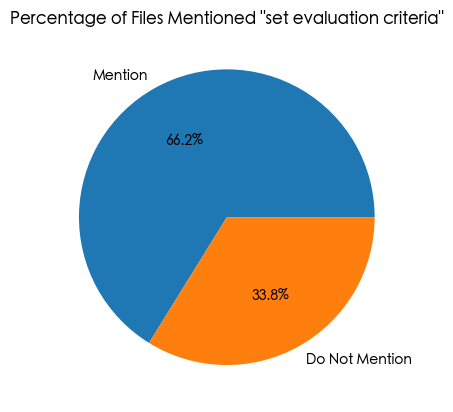

In [9]:
# We can show how many files have the retrieve info
is_mention = len(df[df['Retrieve Info'] != ''])
do_not_mention = len(df[df['Retrieve Info'] == ''])

fig, ax = plt.subplots()
ax.pie([is_mention, do_not_mention], labels=['Mention', 'Do Not Mention'], autopct='%1.1f%%')
plt.title('Percentage of Files Mentioned "set evaluation criteria"')
plt.show()

$\textbf{To analyze the results of retrieval text, we need to remove the policy that do not have retrieval info}$

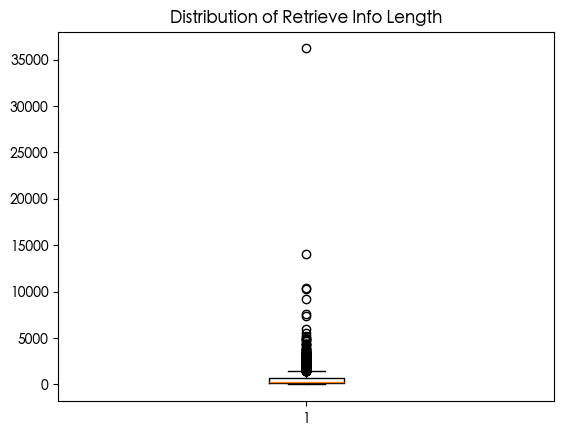

In [10]:
# Box plot to show the distribution of retrieve info length
df_temp = df.copy()
# we drop all the rows that do not have retrieve info
df_temp = df_temp[df_temp['Retrieve Info'] != '']
retrieve_info_length = df_temp['Retrieve Info'].apply(lambda x: len(x))
plt.boxplot(retrieve_info_length)
plt.title('Distribution of Retrieve Info Length')
plt.show()

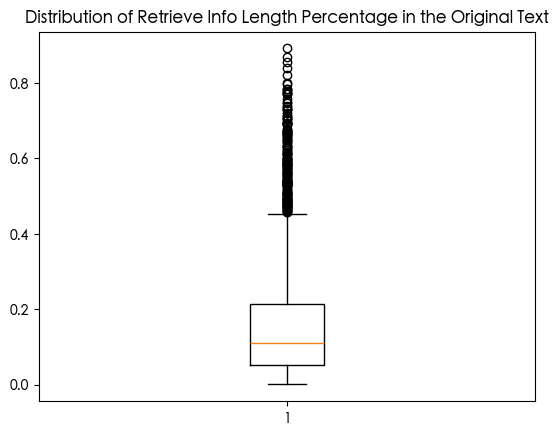

In [11]:
# we can also see the distribution that to what percentage of the document is the retrieve info
df_temp['Retrieve Info Length Percentage'] = df_temp['Retrieve Info Length'] / df_temp['Original Text Length']
plt.boxplot(df_temp['Retrieve Info Length Percentage'])
plt.title('Distribution of Retrieve Info Length Percentage in the Original Text')
plt.show()

In [12]:
# let's show the most three outliar for the retrieve info length
df_temp.sort_values('Retrieve Info Length', ascending=False).head(3)

filename  \
1777  河北省住房和城乡建设厅关于印发《建筑施工安...(FBM-CLI.12.1280747).txt   
2473   湖南省食品药品监督管理局关于发布本局行政执...(FBM-CLI.12.554361).txt   
1239  烟台市海洋与渔业局关于印发《烟台市海洋与渔...(FBM-CLI.12.1788258).txt   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     

In [13]:
# we can also show the most three outliar for the retrieve info length percentage
df_temp.sort_values('Retrieve Info Length Percentage', ascending=False).head(3)

,filename,Retrieve Info,Reason,Original Text Length,Retrieve Info Length,Retrieve Info Length Percentage
4344,宁夏回族自治区发展和改革委员会、中共宁夏区...(FBM-CLI.12.5415222).txt,宁夏回族自治区发展和改革委员会、中共宁夏区委组织部、中共宁夏区委机构编制委员会办公室、宁夏回族自治区科学技术厅、宁夏回族自治区工业和信息化厅、宁夏回族自治区公安厅、宁夏回族自治区财政厅、宁夏回族自治区人力资源和社会保障厅、宁夏回族自治区自然资源厅、宁夏回族自治区住房和城乡建设厅、宁夏回族自治区交通运输厅、宁夏回族自治区水利厅、宁夏回族自治区农业农村厅、宁夏回族自治区商务厅、宁夏回族自治区卫生健康委员会、宁夏回族自治区市场监管厅、宁夏回族自治区国有资产监督管理委员会、宁夏回族自治区公共资源交易管理局、宁夏回族自治区医疗保障局、宁夏回族自治区林业和草原局、银川海关、国家税务总局宁夏回族自治区税务局、中国人民银行银川中心支行、中国银行保险业监督管理委员会宁夏监管局、中国证券监督管理委员会宁夏监管局、中国证券监督管理委员会宁夏监管局关于印发《宁夏回族自治区公共资源交易领域严重失信主体联合惩戒实施办法(试行)》的通知\n宁夏回族自治区发展和改革委员会、中共宁夏区委组织部、中共宁夏区委机构编制委员会办公室、宁夏回族自治区科学技术厅、宁夏回族自治区工业和信息化厅、宁夏回族自治区公安厅、宁夏回族自治区财政厅、宁夏回族自治区人力资源和社会保障厅、宁夏回族自治区自然资源厅、宁夏回族自治区住房和城乡建设厅、宁夏回族自治区交通运输厅、宁夏回族自治区水利厅、宁夏回族自治区农业农村厅、宁夏回族自治区商务厅、宁夏回族自治区卫生健康委员会、宁夏回族自治区市场监管厅、宁夏回族自治区国有资产监督管理委员会、宁夏回族自治区公共资源交易管理局、宁夏回族自治区医疗保障局、宁夏回族自治区林业和草原局、银川海关、国家税务总局宁夏回族自治区税务局、中国人民银行银川中心支行、中国银行保险业监督管理委员会宁夏监管局、中国证券监督管理委员会宁夏监管局、中国证券监督管理委员会宁夏监管局关于印发《宁夏回族自治区公共资源交易领域严重失信主体联合惩戒实施办法(试行)》的通知\n宁夏回族自治区发展和改革委员会、中共宁夏区委组织部、中共宁夏区委机构编制委员会办公室、宁夏回族自治区科学技术厅、宁夏回族自治区工业和信息化厅、宁夏回族自治区公安厅、宁夏回族自治区财政厅、宁夏回族自治区人力资源和社会保障厅、宁夏回族自治区自然资源厅、宁夏回族自治区住房和城乡建设厅、宁夏回族自治区交通运输厅、宁夏回族自治区水利厅、宁夏回族自治区农业农村厅、宁夏回族自治区商务厅、宁夏回族自治区卫生健康委员会、宁夏回族自治区市场监管厅、宁夏回族自治区国有资产监督管理委员会、宁夏回族自治区公共资源交易管理局、宁夏回族自治区医疗保障局、宁夏回族自治区林业和草原局、银川海关、国家税务总局宁夏回族自治区税务局、中国人民银行银川中心支行、中国银行保险业监督管理委员会宁夏监管局、中国证券监督管理委员会宁夏监管局、中国证券监督管理委员会宁夏监管局关于印发《宁夏回族自治区公共资源交易领域严重失信主体联合惩戒实施办法(试行)》的通知,监督\n监督\n监督,1378,1229,0.891872
1193,郑州市市场监督管理局关于对郑州佳龙食品有限...(FBM-CLI.12.6166787).txt,郑州市市场监督管理局关于对郑州佳龙食品有限公司等26家企业食品安全生产规范体系检查情况的通告\n郑州市市场监督管理局关于对郑州佳龙食品有限公司等26家企业食品安全生产规范体系检查情况的通告\n2020年9月1日至10月19日，郑州市市场监督管理局组织食品安全生产规范体系检查工作组，依据《中华人民共和国食品安全法》《食品安全法实施条例》《食品生产许可管理办法》《食品生产经营日常监督检查管理办法》等法律法规，以及《食品安全国家标准食品生产通用卫生规范》（GB14881-2013）《食品安全管理体系食品链中各类组织的要求》（GB/T22000-2006）等国家标准的规定，对郑州佳龙食品有限公司等26家企业食品生产许可条件保持情况、食品安全管理制度落实情况等进行了食品安全生产规范体系检查\n现将检查情况予以通告（详见附件）\n1.郑州佳龙食品有限公司食品安全生产规范体系检查情况\n2.河南万千生物科技有限公司新郑分公司食品安全生产规范体系检查情况\n3.郑州豫恒枣业有限公司食品安全生产规范体系检查情况\n4.河南郑风枣业有限公司食品安全生产规范体系检查情况\n5.新郑市良宝源枣业有限公司食品安全生产规范体系检查情况\n6.河南奇膳一加一健康食品有限公司食品安全生产规范体系检查情况\n7.河南省白大姐食品有限公司食品安全生产规范体系检查情况\n8.郑州高尚枣业有限公司食品安全生产规范体系检查情况\n9.新郑市金田地面业有限公司食品安全生产规范体系检查情况\n10.郑州名厨坊食品有限公司食品安全生产规范体系检查情况\n11.河南华药药业有限公司食品安全生产规范体系检查情况\n12.郑州拙为食品科技有限公司食品安全生产规范体系检查情况\n13.郑州康晖食品科技有限公司食品安全生产规范体系检查情况\n14.郑州科瑞达食品有限公司食品安全生产规范体系检查情况\n15.郑州一品源实业有限公司食品安全生产规范体系检查情况\n16.郑州林诺药业有限公司食品安全生产规范体系检查情况\n17.河南万仁药业有限公司食品安全生产规范体系检查情况\n18.郑州轩生堂药业有限公司食品安全生产规范体系检查情况\n19.郑州金百合生物工程有限公司食品安全生产规范体系检查情况\n20.郑州奥奥食品有限公司食品安全生产规范体系检查情况\n21.郑州四维生物科技有限公司食品安全生产规范体系检查情况\n22.登封市嵩极农产品开发有限责任公司食品安全生产规范体系检查情况\n23.登封市天天一泉饮品有限公司食品安全生产规范体系检查情况\n24.登封市嵩阳酿造有限公司食品安全生产规范体系检查情况\n25.郑州尚善颖水饮品有限公司食品安全生产规范体系检查情况\n26.今麦郎饮品（郑州）有限公司食品安全生产规范体系检查情况\n关于对郑州佳龙食品有限公司等26家企业食品安全生产规范体系检查情况的通告.pdf附件预览,监督\n监督\n监督\n检查\n检查\n检查\n检查\n检查\n检查\n检查\n检查\n检查\n检查\n检查\n检查\n检查\n检查\n检查\n检查\n检查\n检查\n检查\n检查\n检查\n检查\n检查\n检查\n检查\n检查\n检查\n检查,1344,1169,0.869792
2978,南昌市教育局、南昌市发展和改革委员会、南昌...(FBM-CLI.12.5673985).txt,南昌市教育局、南昌市发展和改革委员会、南昌市公安局、南昌市民政局、南昌市财政局、南昌市人力资源和社会保障局、南昌市城乡建设局、南昌市住房保障和房产管理局、南昌市城市管理局、南昌市应急管理局、南昌市市场监督管理局、南昌市行政审批局、国家税务总局南昌市税务局关于印发《南昌市规范校外培训机构发展联席会议制度》《南昌市校外培训机构联合监管责任清单》的通知\n南昌市教育局、南昌市发展和改革委员会、南昌市公安局、南昌市民政局、南昌市财政局、南昌市人力资源和社会保障局、南昌市城乡建设局、南昌市住房保障和房产管理局、南昌市城市管理局、南昌市应急管理局、南昌市市场监督管理局、南昌市行政审批局、国家税务总局南昌市税务局关于印发《南昌市规范校外培训机构发展联席会议制度》《南昌市校外培训机构联合监管责任清单》的通知\n南昌市教育局、南昌市发展和改革委员会、南昌市公安局、南昌市民政局、南昌市财政局、南昌市人力资源和社会保障局、南昌市城乡建设局、南昌市住房保障和房产管理局、南昌市城市管理局、南昌市应急管理局、南昌市市场监督管理局、南昌市行政审批局、国家税务总局南昌市税务局关于印发《南昌市规范校外培训机构发展联席会议制度》《南昌市校外培训机构联合监管责任清单》的通知\n南昌市教育局、南昌市发展和改革委员会、南昌市公安局、南昌市民政局、南昌市财政局、南昌市人力资源和社会保障局、南昌市城乡建设局、南昌市住房保障和房产管理局、南昌市城市管理局、南昌市应急管理局、南昌市市场监督管理局、南昌市行政审批局、国家税务总局南昌市税务局关于印发《南昌市规范校外培训机构发展联席会议制度》《南昌市校外培训机构联合监管责任清单》的通知附件预览,监督\n监督\n监督\n监督,820,703,0.857317


## We can also comparing the statistics results between different labels in our sample by aggrigate the labels from task B ##

In [14]:
df_label = pd.read_csv('policies_label.csv')
df_all = df.join(on='filename', how = 'inner', other = df_label.set_index('filename'))

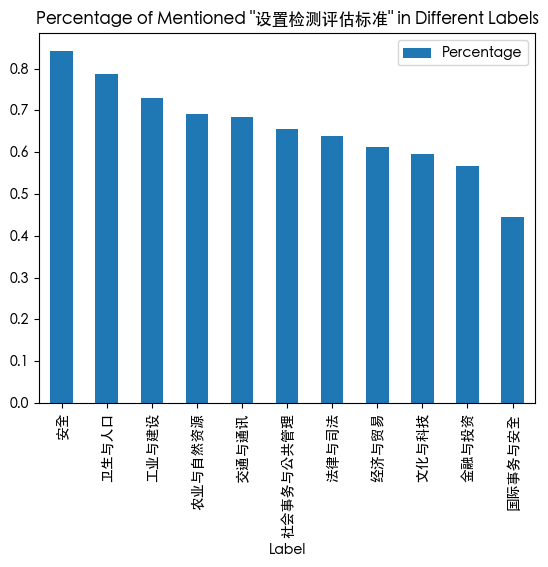

In [15]:
# we use l1 to aggregate the result
agg_result = etrieve_info_length = df_all.groupby('label_L1')

data = []
for name, group in agg_result:
    total = group['Retrieve Info Length'].count()
    mention = group[group['Retrieve Info Length'] != 0]['Retrieve Info Length'].count()
    data.append((name, mention, total, mention/total))

data.sort(key=lambda x: x[3], reverse=True)

# plot the result so we can see the percentage of the mention in different labels
df_plot = pd.DataFrame(data, columns=['Label', 'Mention', 'Total', 'Percentage'])
df_plot.plot(x='Label', y='Percentage', kind='bar')
plt.title('Percentage of Mentioned "设置检测评估标准" in Different Labels')
plt.xticks(rotation=90)
plt.show()

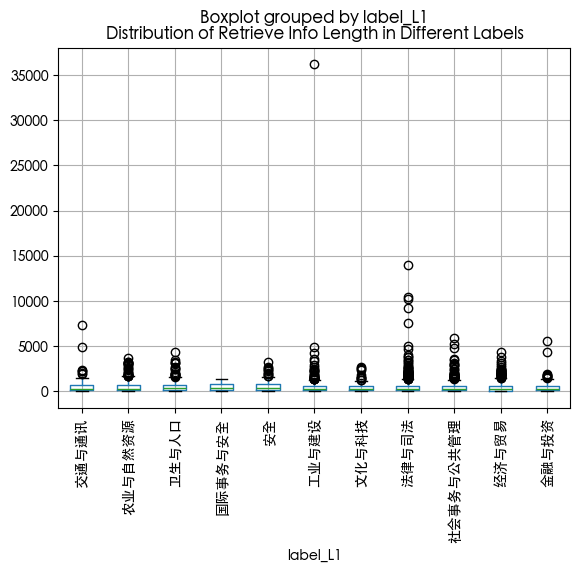

In [16]:
# we can also plot box plot to show the distribution of retrieve info length in different labels
df_temp = df_all.copy()
# we drop all the rows that do not have retrieve info
df_temp = df_temp[df_temp['Retrieve Info'] != '']
df_temp.boxplot(column='Retrieve Info Length', by='label_L1')
plt.title('Distribution of Retrieve Info Length in Different Labels')
plt.xticks(rotation=90)
plt.show()

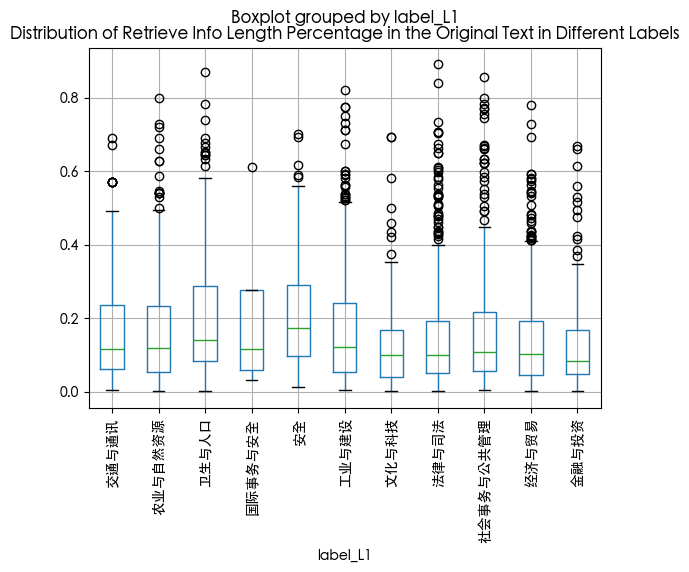

In [17]:
# we can also show the distribution that to what percentage of the document is the retrieve info in different labels
df_temp['Retrieve Info Length Percentage'] = df_temp['Retrieve Info Length'] / df_temp['Original Text Length']
df_temp.boxplot(column='Retrieve Info Length Percentage', by='label_L1')
plt.title('Distribution of Retrieve Info Length Percentage in the Original Text in Different Labels')
plt.xticks(rotation=90)
plt.show()